My goal for now is to make a minimum viable solution using convolutional networks in PyTorch. Some code (mainly related to visualization) was copied with modifications from https://www.kaggle.com/code/kanncaa1/pytorch-tutorial-for-deep-learning-lovers and https://www.kaggle.com/code/yt776styjsu/99-5-introduction-to-cnn-w-pytorch. Current network architecture is from https://www.kaggle.com/code/ayushrathi47/digit-recognizer-using-tensorflow-cnn/notebook?scriptVersionId=101956744. Many thanks to these notebooks' authors!

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
train_data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test_data = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

In [3]:
train_data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test_data

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
n_labels = train_data['label'].nunique()

In [6]:
n_pixels = test_data.shape[1]

In [7]:
y = train_data.pop('label').values
X = train_data.values.astype(np.float32) / 255
X_test = test_data.values.astype(np.float32) / 255
X, y, X_test

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([1, 0, 1, ..., 7, 6, 9]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

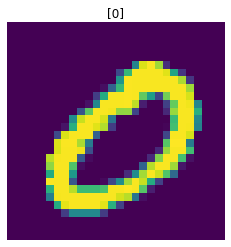

In [8]:
import random
import matplotlib.pyplot as plt

idx = train_data.sample().index
plt.imshow(X[idx].reshape(28,28))
plt.axis("off")
plt.title(str(y[idx]))
plt.savefig('graph.png')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y,test_size = 0.1,random_state = 42) 

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [11]:
X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train).type(torch.LongTensor) 
X_val = torch.from_numpy(X_val)
y_val = torch.from_numpy(y_val).type(torch.LongTensor) 
X_test = torch.from_numpy(X_test)
y_test = torch.zeros(X_test.size(dim=0))

In [12]:
train = torch.utils.data.TensorDataset(X_train,y_train)
val = torch.utils.data.TensorDataset(X_val,y_val)
test = torch.utils.data.TensorDataset(X_test,y_test)

In [13]:
batch_size = 100

In [14]:
train_loader = DataLoader(train, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = False)

In [15]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding='valid'),
            nn.ReLU(),
            # nn.Dropout(p=0.1),
            nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding='valid'),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding='valid'),
            nn.ReLU(),
            # nn.Dropout(p=0.1),
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=1, padding='valid'),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(144, 64),
            nn.ReLU(),
            nn.Linear(64, n_labels)
        )
        
                
    def forward(self, X):
        out = self.layers(X)
        return out

In [16]:
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.layers = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(84), nn.ReLU(),
            nn.LazyLinear(num_classes)
        )
    def forward(self, X):
        out = self.layers(X)
        return out

In [17]:
input_dim = n_pixels
output_dim = n_labels

n_iters = 50000
num_epochs = n_iters // (len(X_train) // batch_size)

In [18]:
batch_view_dims = (batch_size, 1, 28, 28)

# model =  CNNModel() 
model = LeNet(num_classes=10)
model.layers(torch.randn(batch_view_dims))

error = nn.CrossEntropyLoss()
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

/opt/conda/lib/python3.7/site-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [19]:
from torch.autograd import Variable

count = 0
loss_list = []
iteration_list = []
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        
        train = Variable(images.view(batch_view_dims))
        labels = Variable(labels)
       
        optimizer.zero_grad()
        outputs = model(train)
        
        loss = error(outputs, labels)
        loss.backward()
        optimizer.step()
        
        count += 1
        
        if count % 100 == 0:
            correct = 0
            total = 0
            
            for images, labels in val_loader: 
                val = Variable(images.view(batch_view_dims))
                outputs = model(val)
                # print(outputs.data)
                predicted = torch.max(outputs.data, 1).indices 
                
                total += len(labels)
                correct += (predicted == labels).sum()
            
            accuracy = 100 * correct / float(total)
            
            iteration_list.append(count)
            loss_list.append(loss.data)            
            
        if count % 500 == 0:
            print('Iteration: {}  Loss: {}  Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500  Loss: 0.049680471420288086  Accuracy: 96.76190185546875%
Iteration: 1000  Loss: 0.04616289213299751  Accuracy: 97.52381134033203%
Iteration: 1500  Loss: 0.026084067299962044  Accuracy: 98.02381134033203%
Iteration: 2000  Loss: 0.005540239624679089  Accuracy: 98.14286041259766%
Iteration: 2500  Loss: 0.030996238812804222  Accuracy: 97.88095092773438%
Iteration: 3000  Loss: 0.10684637725353241  Accuracy: 98.19047546386719%
Iteration: 3500  Loss: 0.04722626507282257  Accuracy: 98.30952453613281%
Iteration: 4000  Loss: 0.10167130827903748  Accuracy: 97.97618865966797%
Iteration: 4500  Loss: 0.025422222912311554  Accuracy: 98.04762268066406%
Iteration: 5000  Loss: 0.022201497107744217  Accuracy: 98.42857360839844%
Iteration: 5500  Loss: 0.029470713809132576  Accuracy: 98.21428680419922%
Iteration: 6000  Loss: 0.0489451140165329  Accuracy: 98.47618865966797%
Iteration: 6500  Loss: 0.025326533243060112  Accuracy: 98.19047546386719%
Iteration: 7000  Loss: 0.06942739337682724  A

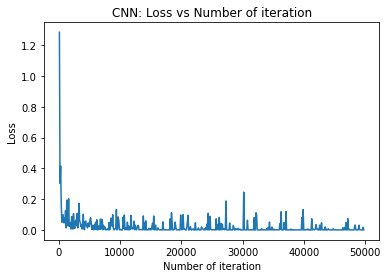

In [20]:

plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

In [21]:
with torch.no_grad():
    model.eval()
    results = torch.LongTensor()
    for images, _ in test_loader:
        predictions = model(images.view(batch_view_dims))
        pred_labels = torch.max(predictions.data, 1).indices
        results = torch.cat((results, pred_labels), dim=0) 
results

tensor([2, 0, 9,  ..., 3, 9, 2])

In [22]:
output = pd.DataFrame({'ImageId': test_data.index + 1, 'Label': results.numpy().flatten()})
output.to_csv('submission.csv',index=False)
print("Your submission was successfully saved!")
output

Your submission was successfully saved!


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,3
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


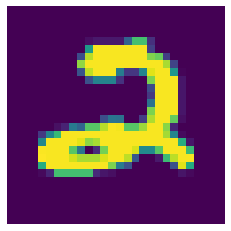

In [23]:
plt.imshow(X_test[0].reshape(28,28))
plt.axis("off")
plt.savefig('graph.png')
plt.show()